In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import json

In [2]:
path='C:/Users/raffi/OneDrive - United Nations/Desktop/DSS/DATA AVAILABILITY INTERACTIVE DASHBOARD'
datafile='final_dataset_combined.xlsx'

full_path = os.path.join(path, datafile)

# Read the Excel file
data = pd.read_excel(full_path)

In [3]:
print(data['القطاع المؤسسي'].unique())
print(data['القطاع'].unique())

[nan 'قطاع عام' 'قطاع خاص' 'مختلط' 'أخرى']
[nan 'جميع القطاعات' 'خاص' 'عام']


In [4]:
data.columns

Index(['المؤشر', 'الدولة', 'الفصل', 'السنة', 'العدد', 'المصدر', 'المواطنة',
       'الجنس', 'المرحلة التعليمية', 'الفئة العمرية', 'المنطقة',
       'مصدر الإضاءة', 'أنواع نظام التخلص من مياه الصرف الصحي',
       'نوع حيازة الوحدات السكنية', 'مصدر مياه الشرب', 'نوع مكان الإقامة',
       'القطاع المؤسسي', 'أقسام المهن الرئيسية', 'أقسام النشاط الإقتصادي',
       'وضع العمالة', 'أسباب البقاء خارج القوى العاملة',
       'التصنيف الدولي لاسباب الوفاة', 'سبب الوفاة', 'الحالة الزوجية', 'الفئة',
       'نوع الخدمات/المنتجات', 'القطاع'],
      dtype='object')

### Translate

In [5]:
#read in the dictionary
path='C:/Users/raffi/OneDrive - United Nations/Desktop/DSS/DATA COLLECTOR'
df_translation=pd.read_excel(path+'/translation dict.xlsx')

In [6]:
df_translation.head()

,col_en,val_en,col_ar,val_ar
0,Age Group,0-1 years,الفئة العمرية,0-1 سنة
1,Age Group,0-4 years,الفئة العمرية,0-4 سنوات
2,Age Group,5-17 years,الفئة العمرية,5-17 سنة
3,Age Group,10-14 years,الفئة العمرية,10-14 سنة
4,Age Group,1-4 years,الفئة العمرية,1-4 سنوات


In [7]:
En_Ar_dictionary={}
#get the unique dimensions
# dimensions = set(df_translation['col_en'].unique()) - {'Year', 'Value', 'Source'}
dimensions = df_translation['col_en'].unique()

for dim in dimensions:
    df_dim=df_translation[df_translation['col_en'].isin([dim.lower(), dim])].copy()
    En_Ar_dictionary.update(
        {dim:{'dim_values':dict(zip(df_dim['val_en'], df_dim['val_ar'])), 
                'dim': {df_dim['col_en'].unique()[0]:df_dim['col_ar'].unique()[0]}}})

Ar_En_dictionary={}
#get the unique dimensions
# dimensions = set(df_translation['col_ar'].unique()) - {'السنة', 'العدد', 'المصدر'}
dimensions = df_translation['col_ar'].unique()

for dim in dimensions:
    df_dim=df_translation[df_translation['col_ar'].isin([dim.lower(), dim])].copy()
    Ar_En_dictionary.update(
        {dim:{'dim_values':dict(zip(df_dim['val_ar'], df_dim['val_en'])), 
                'dim': {df_dim['col_ar'].unique()[0]:df_dim['col_en'].unique()[0]}}})
    
###################################################################################################
    
class Translator:
    def __init__(self, translate_to, En_Ar_dictionary, Ar_En_dictionary):
        self.translate_to = translate_to.lower()
        self.en_ar_dict = En_Ar_dictionary
        self.ar_en_dict = Ar_En_dictionary

    def translate(self, df):
        df_translated = df.copy()
        
        # Pick the dictionary based on direction
        mapping = self.ar_en_dict if self.translate_to == 'english' else self.en_ar_dict
        
        for col, col_dict in mapping.items():
            if col in df_translated.columns:
                #Replace the data values (e.g., 'Male' -> 'ذكر')
                df_translated[col] = df_translated[col].replace(col_dict['dim_values'])
                
                #Rename the column header (e.g., 'Gender' -> 'الجنس')
                df_translated.rename(columns=col_dict['dim'], inplace=True)
                
        return df_translated

In [8]:
translator = Translator('english',En_Ar_dictionary, Ar_En_dictionary)
en_df_translated = translator.translate(data)

In [9]:
en_df_translated.columns

Index(['Indicator', 'Country', 'Chapter', 'Year', 'Value', 'Source',
       'Nationality', 'Sex', 'Education level', 'Age Group', 'Area',
       'Source of Lighting', 'Types of sewage disposal system',
       'Tenure of housing unit', 'Source of water supply',
       'Type of living quarter', 'Institutional sector', 'Main occupation',
       'Economic activity', 'Employment status', 'Reasons for inactivity',
       'International classification for causes of death', 'Causes of death',
       'Marital status', 'Quintile', 'Types of products/services',
       'Educational sector'],
      dtype='object')

In [10]:
en_df_translated['Chapter'].unique()

array(['Education', 'Health', 'Housing', 'Labor', 'Population', 'Poverty'],
      dtype=object)

### Produce charts

6.1_test.svg


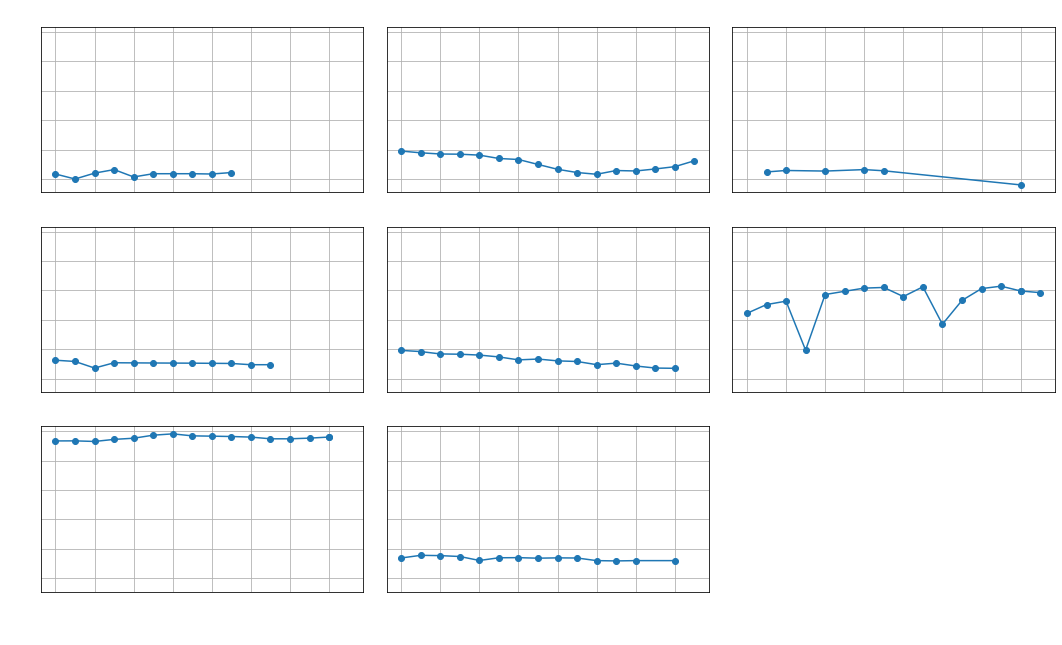

In [63]:
#LABOR
df_labor=en_df_translated[en_df_translated['Chapter']=='Labor'].copy()

###Labor, 6.1 Labor force participation rate
condition = (
    (df_labor['Indicator'] == 'Labor force participation rate') & 
    (df_labor['Age Group'] == '15+ years') & 
    (~df_labor['Sex'].isin(['Male', 'Female'])) &
    (~df_labor['Nationality'].isin(['Nationals', 'Non-nationals']))
)

df_labor61 = df_labor[condition].copy()
####################################################################
# 1. Prepare data
df_labor61['Year'] = pd.to_numeric(df_labor61['Year'], errors='coerce')
df_labor61['Value'] = pd.to_numeric(df_labor61['Value'], errors='coerce')
df_labor61 = df_labor61.dropna(subset=['Year', 'Value'])

countries = sorted(df_labor61['Country'].unique())
num_countries = len(countries)
cols = 3
rows = (num_countries + cols - 1) // cols


# 2. Plot
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 3), sharex=True, sharey=True)
axes_flat = np.array(axes).flatten()

# Apply white text globally for this figure to avoid black text issues
plt.rcParams.update({'text.color': 'white', 'axes.labelcolor': 'white', 'xtick.color': 'white', 'ytick.color': 'white'})

for i, country in enumerate(countries):
    subset = df_labor61[df_labor61['Country'] == country].sort_values('Year')
    ax=axes_flat[i]
    ax.plot(subset['Year'], subset['Value'], marker='o')

    ax.set_title(country, color='white', fontsize=12, pad=10)
    ax.grid(True)


# AMENDED: Set labels for the entire figure with white color
fig.supxlabel('Year', fontsize=14, color='white')
fig.supylabel('Value', fontsize=14, color='white')


# 3. Clean layout
for j in range(len(countries), len(axes_flat)):
    axes_flat[j].axis('off')

# Save as SVG
svg_file = "6.1_test.svg"
plt.savefig(svg_file, format='svg', transparent=True)
print(svg_file)

plt.tight_layout()
plt.show()



In [55]:
df_labor61.to_excel('6.1.xlsx')

In [47]:
df_61=df_labor61[['Indicator','Sex','Nationality','Year','Value']].copy()

In [49]:
print(df_61['Sex'].unique())
print(df_61['Nationality'].unique())
print(df_61['Year'].unique())

['Both sexes']
['Nationality Total']
[2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023
 2024 2025 2026 2027 2028 2029 2030]


In [ ]:
#get the data subsets for the charts

#LABOR
df_labor=en_df_translated[en_df_translated['Chapter']=='Labor'].copy()

###Labor, 6.1 Labor force participation rate, 15+
condition = (
    (df_labor['Indicator'] == 'Labor force participation rate') & 
    (df_labor['Age Group'] == '15+ years') & 
    (~df_labor['Sex'].isin(['Male', 'Female'])) &
    (~df_labor['Nationality'].isin(['Nationals', 'Non-nationals']))
)

df_labor61 = df_labor[condition].copy()

###Labor, 6.2 Labour force participation rate, by sex
condition = (
    (df_labor['Indicator'] == 'Labor force participation rate') & 
    (~df_labor['Nationality'].isin(['Nationals', 'Non-nationals'])) & 
    (df_labor['Sex'].isin(['Male', 'Female']))
)

df_labor62 = df_labor[condition].copy()

###Labor, 6.3 Youth labour force participation rate (15–24 years), by sex
condition = (
    (df_labor['Indicator'] == 'Labor force participation rate') & 
    (~df_labor['Nationality'].isin(['Nationals', 'Non-nationals'])) & 
    (df_labor['Age Group'] == '15-24 years') &
    (df_labor['Sex'].isin(['Male', 'Female']))
)

df_labor63 = df_labor[condition].copy()

###Labor, 6.4 Unemployment rate
condition = (
    (df_labor['Indicator'] == 'Unemployment rate') & 
    (~df_labor['Nationality'].isin(['Nationals', 'Non-nationals'])) & 
    (~df_labor['Sex'].isin(['Male', 'Female']))
)

df_labor64 = df_labor[condition].copy()

###Labor, 6.5 Unemployment rate, by sex
condition = (
    (df_labor['Indicator'] == 'Unemployment rate') & 
    (~df_labor['Nationality'].isin(['Nationals', 'Non-nationals'])) & 
    (df_labor['Sex'].isin(['Male', 'Female']))
)

df_labor65 = df_labor[condition].copy()

###Labor, 6.6 Youth unemployment rate (15–24 years), by sex
condition = (
    (df_labor['Indicator'] == 'Unemployment rate') & 
    (~df_labor['Nationality'].isin(['Nationals', 'Non-nationals'])) & 
    (df_labor['Age Group'] == '15-24 years') &
    (df_labor['Sex'].isin(['Male', 'Female']))
)

df_labor66 = df_labor[condition].copy()

###Labor, 6.7 Employment in the public sector, percentage, by sex
condition = (
    (df_labor['Indicator'] == 'Employment (15 years and over) by sector (percent)') & 
    (~df_labor['Nationality'].isin(['Nationals', 'Non-nationals'])) & 
    (~df_labor['Sex'].isin(['Male', 'Female'])) &
    (df_labor['Institutional Sector'] == 'Public')
)

df_labor67 = df_labor[condition].copy()

###Labor, 6.8 Employment in agriculture, percentage, by sex
condition = (
    (df_labor['Indicator'] == 'Employment (15 years and over) by sector (percent)') & 
    (~df_labor['Nationality'].isin(['Nationals', 'Non-nationals'])) & 
    (~df_labor['Sex'].isin(['Male', 'Female'])) &
    (df_labor['Economic activity'] == 'Agriculture')
)

df_labor67 = df_labor[condition].copy()

########################################################################################
########################################################################################
########################################################################################


#POVERTY
df_poverty=en_df_translated[en_df_translated['Chapter']=='Poverty'].copy()

###poverty, 7.1	Proportion of the population living below the national poverty line (percent)
condition = (
    (df_poverty['Indicator'] == 'Proportion of the population living below the national poverty line (percent)') &
    (~df_poverty['Sex'].isin(['Male', 'Female'])) &
    (~df_poverty['Nationality'].isin(['Nationals' ,'Non-nationals']))
)

df_poverty71 = df_poverty[condition].copy()

###poverty, 7.2	Poverty gaps
condition = (
    (df_poverty['Indicator'] == 'Poverty gap at national poverty line (percent)') &
    (~df_poverty['Sex'].isin(['Male', 'Female'])) &
    (~df_poverty['Nationality'].isin(['Nationals' ,'Non-nationals']))
)

df_poverty72 = df_poverty[condition].copy()

###poverty, 7.3	Gini index
condition = (
    (df_poverty['Indicator'] == 'GINI Index ') &
    (~df_poverty['Sex'].isin(['Male', 'Female'])) &
    (~df_poverty['Nationality'].isin(['Nationals', 'Non-nationals']))
)

df_poverty73 = df_poverty[condition].copy()

###poverty, 7.4	Share of total consumption expenditure by richest and poorest quintiles
condition = (
    (df_poverty['Indicator'] == 'Share of consumption expenditure (percent)') &
    (~df_poverty['Sex'].isin(['Male', 'Female'])) &
    (~df_poverty['Nationality'].isin(['Nationals' ,'Non-nationals']))
)

df_poverty74 = df_poverty[condition].copy()

###poverty, 7.5	'Expenditure shares (percent)'
condition = (
    (df_poverty['Indicator'] == 'Expenditure shares (percent)') &
    (~df_poverty['Sex'].isin(['Male', 'Female'])) &
    (~df_poverty['Nationality'].isin(['Nationals', 'Non-nationals']))
)

df_poverty75 = df_poverty[condition].copy()


########################################################################################
########################################################################################
########################################################################################


#POPULATION
df_population=en_df_translated[en_df_translated['Chapter']=='Population'].copy()

###population, 1.1	Annual population growth rate, per cent
condition = (
    (df_population['Indicator'] == 'Average annual population growth rate') &
    (~df_population['Sex'].isin(['Male', 'Female'])) &
    (~df_population['Nationality'].isin(['Nationals' ,'Non-nationals'])) &
    (~df_population['Area'].isin['Urban', 'Rural'])
)

df_pop11 = df_population[condition].copy()

###population, 1.2	Population size in millions
condition = (
    (df_population['Indicator'] == 'Population size by nationality') &
    (~df_population['Sex'].isin(['Male', 'Female'])) &
    (~df_population['Nationality'].isin(['Nationals' ,'Non-nationals'])) &
    (~df_population['Area'].isin['Urban', 'Rural'])
)

df_pop12 = df_population[condition].copy()

###population, 1.3	Sex composition of nationals versus non-nationals in selected Gulf Cooperation Council countries

countries=['Oman','Qatar', 'Saudi Arabia', 'Bahrain','Kuwait','United Arab Emirates']
condition = (
    (df_population['Indicator'] == 'Population size by nationality') &
    (df_population['Sex'].isin(['Male', 'Female'])) &
    (df_population['Nationality'].isin(['Nationals' ,'Non-nationals'])) &
    (~df_population['Area'].isin['Urban' ,'Rural']) &
    (df_population['Country'].isin(countries)) 
)

df_pop13 = df_population[condition].copy()


###population, 1.4	Egypt: population pyramid; life expectancy and fertility rate


###population, 1.5	Bahrain: population pyramid; life expectancy and fertility rate


###population, 1.6	Sex ratios (Per 100 females)


###population, 1.7	Percentage of population by age group and by sex


###population, 1.8	Total fertility rates among women aged 15–49 years (Births per woman)


###population, 1.9	Life expectancy at birth for total population, by sex

###population, 2.1	Average household size

###population, 2.2	Female-headed households, percentage

###population, 2.3	Registered marriages, in millions

###population, 2.4	Registered divorces, in thousands

###population, 2.5	Mean age at first marriage

###population, 2.6	Proportion of women aged 20-24 who were married or in a union before age 18 (%)

########################################################################################
########################################################################################
########################################################################################


#EDUCATION
df_education=en_df_translated[en_df_translated['Chapter']=='Education'].copy()

###education, 5.1	Adult literacy, ages 15 and over, percentage, by sex

###education, 5.2	Youth literacy, ages 15–24, percentage, by sex

###education, 5.3	Primary education enrolment ratio, by sex

###education, 5.4	Secondary education enrolment ratio, by sex

###education, 5.5	Pupil-teacher ratio in primary education

###education, 5.6	Pupil-teacher ratio in secondary education

###education, 5.7	Expenditure on education as a percentage of total government expenditure


########################################################################################
########################################################################################
########################################################################################


#HEALTH
df_health=en_df_translated[en_df_translated['Chapter']=='Health'].copy()

####health, 4.1	Contraceptive prevalence rates, percentage

####health, 4.2	Prenatal care, percentage (At least four visits)
####health, 4.3	Births attended by a skilled health professional, percentage
####health, 4.4	Maternal mortality ratios (Deaths per 100,000 live births)
####health, 4.5	Immunization coverage rates, percentage
####health, 4.6	Stunting by sex, latest available data
####health, 4.7	Wasting by sex, latest available data
####health, 4.8	Underweight by sex, latest available data
####health, 4.9	Disability prevalence, percentage, by sex, latest available data
####health, 4.10	Obese adults (18 years and older), percentage, by sex
####health, 4.11	Government expenditure on healthcare as a percentage of gross domestic product
####health, 4.12	Per capita government expenditure on health (in United States dollars)
####health, 4.13	Density of health-care personnel per 10,000 population
####health, 4.14	Number of hospitals, 2000-2023





########################################################################################
########################################################################################
########################################################################################

#HOUSING
df_housing=en_df_translated[en_df_translated['Chapter']=='Housing'].copy()

####housing 3.1	Occupied housing units by tenure of housing unit, latest available data (Percentage)

#####housing 3.2	Occupied housing units by type of living quarters by area, latest available data (Urban or rural), (Percentage)

#####housing 3.3	Percentage of households using an improved drinking water source, by area, latest available data (Urban or rural)

#####housing 3.4	Percentage of households with access to improved sanitation, by area, latest available data (Urban or rural)

#####housing 3.5	Percentage of households with access to electricity, by area, latest available data (Urban or rural)

#####housing 3.6	Internet users, percentage of population

#####housing 3.7	Mobile cellular subscriptions per 100 inhabitants




KeyError: 'Age group'

In [34]:
df_poverty=en_df_translated[en_df_translated['Chapter']=='Poverty'].copy()
df_labor=en_df_translated[en_df_translated['Chapter']=='Labor'].copy()
df_population=en_df_translated[en_df_translated['Chapter']=='Population'].copy()
df_housing=en_df_translated[en_df_translated['Chapter']=='Housing'].copy()
df_education=en_df_translated[en_df_translated['Chapter']=='Education'].copy()
df_health=en_df_translated[en_df_translated['Chapter']=='Health'].copy()

In [42]:
df_labor.columns

Index(['Indicator', 'Country', 'Chapter', 'Year', 'Value', 'Source',
       'Nationality', 'Sex', 'Education level', 'Age Group', 'Area',
       'Source of Lighting', 'Types of sewage disposal system',
       'Tenure of housing unit', 'Source of water supply',
       'Type of living quarter', 'Institutional sector', 'Main occupation',
       'Economic activity', 'Employment status', 'Reasons for inactivity',
       'International classification for causes of death', 'Causes of death',
       'Marital status', 'Quintile', 'Types of products/services',
       'Educational sector'],
      dtype='object')

In [29]:
df_population['Country'].unique()

array(['Algeria', 'Egypt', 'Iraq', 'Mauritania', 'Morocco', 'Oman',
       'Qatar', nan, 'Tunisia'], dtype=object)

In [ ]:
df_health['Indicator'].unique()

In [28]:
print(df_population['Nationality'].unique())
print(df_population['Sex'].unique())
print(df_population['Age Group'].unique())
print(df_population['Area'].unique())

[nan 'Nationality Total' 'Nationals' 'Non-nationals']
['Male' 'Female' 'Both sexes' nan 'حضر' 'ريف']
[nan '15-19 years' '20-24 years' '25-29 years' '30-34 years' '35-39 years'
 '40-44 years' '45-49 years' '0-4 years' '5-9 years' '10-14 years'
 '50-54 years' '55-59 years' '60-64 years' '65-69 years' '70-74 years'
 '75+ years' 'Age unknown' 'Age Total']
['Urban' 'Rural' 'Area Total' nan 'مجموع المواطنين وغير المواطنين'
 'مواطنون' 'غير مواطنين']


#### Labor

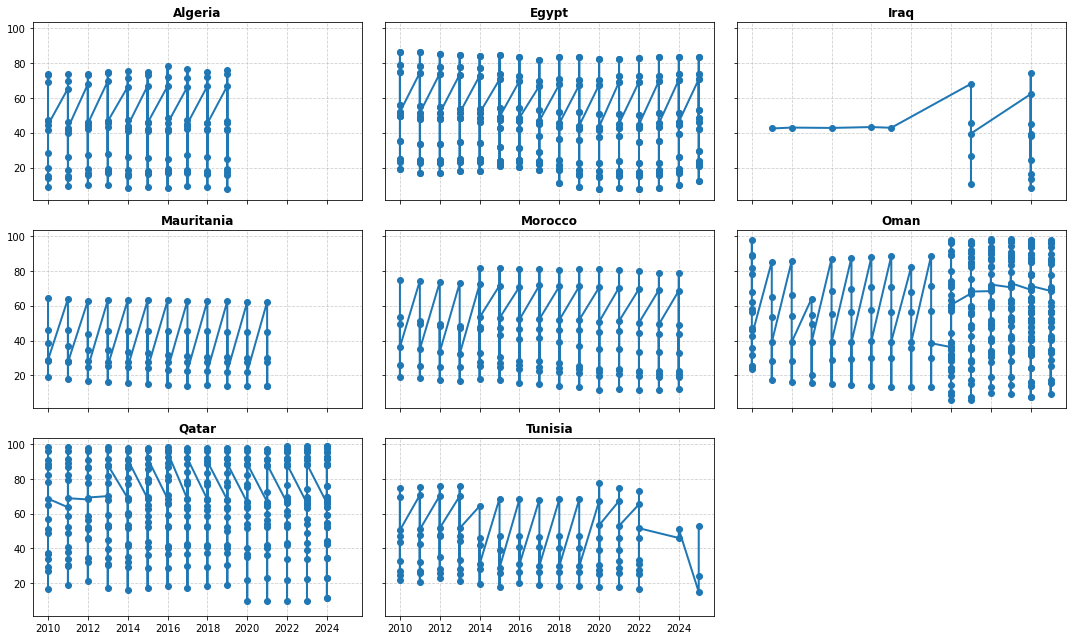

In [ ]:
df_labor=en_df_translated[en_df_translated['Chapter']=='Labor'].copy()

########################Labor, 6.1 'Labor force participation rate'
df_labor1=df_labor[df_labor['Indicator']== 'Labor force participation rate'].copy()

# 1. Force conversion of these columns to numeric (numbers)
# 'coerce' will turn non-numeric values (like text or errors) into NaN, 
# which matplotlib handles better than mixed data types.
df_labor1['Year'] = pd.to_numeric(df_labor1['Year'], errors='coerce')
df_labor1['Value'] = pd.to_numeric(df_labor1['Value'], errors='coerce')

# 2. Drop any rows where Year or Value might have become NaN after conversion
df_labor1 = df_labor1.dropna(subset=['Year', 'Value'])

# get countries
countries = list(df_labor1['Country'].unique())

num_countries = len(countries)
# Dynamic Grid Calculation
cols = 3
rows = (num_countries // cols) + (1 if num_countries % cols != 0 else 0)

# Setup Plot
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 3), sharex=True, sharey=True)
axes_flat = axes.flatten()

# Plotting
for i, ax in enumerate(axes_flat):
    if i < num_countries:
        country_name = countries[i]
        subset = df_labor1[df_labor1['Country'] == country_name]
        
        ax.plot(subset['Year'], subset['Value'], marker='o', linestyle='-', linewidth=2)
        ax.set_title(country_name, fontsize=12, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.6)
    else:
        # Hide empty subplots
        ax.axis('off')

plt.tight_layout()

# Save as SVG
# plt.savefig("data_dashboard.svg", format="svg")
plt.show()

In [60]:
df_labor['Indicator'].unique()

array(['Unemployment rate',
       'Children aged 5-17 engaged in child labor (percent)',
       'Percentage of youth (aged 15-24) outside education, training, and work\xa0',
       'Employment (15 years and over) by sector (percent)',
       'Employment (15 years and over) by occupation (percent)',
       'Employment (15 years and over) by economic activity (percent)',
       'Employment status (15 years and over) (percent)',
       'Persons outside the labor force aged 15 and over by reason of activity (percent)',
       'Persons outside the labor force aged 15 and over (percent)',
       'Labor force participation rate', 'Employment to population ratio'],
      dtype=object)